# **Actividad — Análisis de Grandes Volúmenes de Datos**

### **Maestría en Inteligencia Artificial Aplicada**
### **Curso: TC5057 · Análisis de Grandes Volúmenes de Datos**
#### **Tecnológico de Monterrey**
##### **Prof [Nombre del Profesor]**

---

### **Equipo [#]**

| Nombre | Matrícula |
|--------|-----------|
| Ana Bonavides Aguilar | A01423281 |
|  |  |
|  |  |

## Objetivo General

Analizar los patrones de expresión génica en múltiples tipos de tejido humano para identificar marcadores biológicos relevantes para el monitoreo de la salud de astronautas, estableciendo una línea base genómica terrestre que la medicina espacial utiliza para detectar desviaciones causadas por el vuelo espacial.

### Contexto

Con la misión Artemis II de la NASA actualmente en curso, la medicina espacial estudia activamente cómo el vuelo espacial altera el cuerpo humano a nivel molecular. La microgravedad, la radiación cósmica y el estrés de misión modifican la **expresión génica** — qué tan activamente funcionan los genes — sin cambiar el ADN subyacente. Para detectar estas desviaciones, los investigadores necesitan una línea base terrestre normal.

El dataset GTEx proporciona exactamente eso: un mapa completo de la expresión génica humana en 54 tipos de tejido de casi 1,000 donantes sanos, financiado por el NIH Common Fund y mantenido por el Broad Institute del MIT y Harvard.

## Dataset

| Campo | Detalle |
|-------|---------|
| **Nombre** | GTEx Analysis V10 — Gene Expression TPM |
| **Origen** | NIH / Broad Institute — Genotype-Tissue Expression Project |
| **Liga** | https://gtexportal.org/home/downloads/adult-gtex |
| **Archivo** | `GTEx_Analysis_2022-06-06_v10_RNASeQCv2.4.2_gene_tpm_non_lcm.gct` |
| **Tamaño** | ~6.8 GB (sin comprimir) — supera el requisito mínimo de 1 GB |
| **Formato** | GCT 1.2 (TSV con 2 filas de metadatos al inicio) |
| **Contenido** | ~59,000 genes × ~19,600 muestras de tejido humano |
| **Acceso** | Abierto — sin login ni IRB requerido |

El dataset contiene valores de **TPM (Transcripts Per Million)**: una medida de expresión génica normalizada por longitud del gen y profundidad de secuenciación, comparable entre muestras.

In [1]:
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import FloatType
from functools import reduce

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("GTEx_TC5057") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/03 05:52:47 WARN Utils: Your hostname, AnniesSpaceShip.local, resolves to a loopback address: 127.0.0.1; using 192.168.4.23 instead (on interface en0)
26/05/03 05:52:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/03 05:52:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1. Estructura del Dataset

El formato GCT 1.2 tiene 2 líneas de metadatos al inicio del archivo antes del encabezado real:
- **Línea 1:** `#1.2` — versión del formato
- **Línea 2:** `59033\t19616` — dimensiones del dataset
- **Línea 3:** encabezado real con `Name`, `Description` y los IDs de las ~19,600 muestras

Esto hace que `spark.read.csv(comment="#")` no funcione directamente — saltaría la línea 1 pero trataría la línea 2 (las dimensiones) como encabezado. La solución es extraer los nombres de columnas con pandas (solo lee 3 líneas) y cargar los datos con PySpark filtrando por contenido.

In [3]:
file_path = "GTEx_Analysis_2022-06-06_v10_RNASeQCv2.4.2_gene_tpm_non_lcm.gct"

# grab column names with pandas — way faster than spark for reading just 3 lines
peek = pd.read_csv(file_path, sep='\t', skiprows=2, nrows=3)
all_col_names = peek.columns.tolist()

n_genes   = 59033
n_samples = len(all_col_names) - 2  # minus Name and Description

print(f"Genes:   {n_genes:,}")
print(f"Samples: {n_samples:,}")
print(f"Tamaño:  ~6.8 GB (sin comprimir)")
print(f"\nPrimeras 6 columnas: {all_col_names[:6]}")

peek.iloc[:, :6]

Genes:   59,033
Samples: 19,616
Tamaño:  ~6.8 GB (sin comprimir)

Primeras 6 columnas: ['Name', 'Description', 'GTEX-1117F-0005-SM-HL9SH', 'GTEX-1117F-0011-R10b-SM-GI4VE', 'GTEX-1117F-0011-R11b-SM-GIN8R', 'GTEX-1117F-0011-R2b-SM-GI4VL']


,Name,Description,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL
0,ENSG00000223972.5,DDX11L1,0.00000,0.00000,0.0000,0.0000
1,ENSG00000227232.5,WASH7P,1.33343,3.57928,10.1893,2.9665
2,ENSG00000278267.1,MIR6859-1,0.00000,0.00000,0.0000,0.0000


In [4]:
# every 100th sample so we don't kill the laptop — ~196 samples is plenty for stats
step = 100
selected_indices = [0, 1] + list(range(2, len(all_col_names), step))
selected_cols    = [all_col_names[i] for i in selected_indices]

# clean up column names — spark doesn't like hyphens or dots in col names
clean_names = [c.replace('-', '_').replace('.', '_') for c in selected_cols]
sample_cols = clean_names[2:]  # everything after Name and Description

print(f"Usando {len(sample_cols)} columnas de muestra (cada {step}a muestra de las {n_samples:,})")

# load with spark — filter to lines starting with ENSG to skip the 3 GCT header rows
# all real gene rows have ENSEMBL IDs starting with ENSG, clean and no shuffle needed
raw_rdd = spark.sparkContext.textFile(file_path)

data_rdd = (
    raw_rdd
    .filter(lambda line: line.startswith('ENSG'))   # skip version, dimensions, and header rows
    .map(lambda line: line.split('\t'))
    .map(lambda fields: [fields[i] for i in selected_indices])
)

df_raw = data_rdd.toDF(clean_names)
print(f"\nDataFrame cargado: {df_raw.count():,} genes x {len(clean_names)} columnas")

Usando 197 columnas de muestra (cada 100a muestra de las 19,616)


26/05/03 05:52:51 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.



DataFrame cargado: 59,033 genes x 199 columnas


In [5]:
# cast to float — spark reads text files as strings by default
df = df_raw
for c in sample_cols:
    df = df.withColumn(c, F.col(c).cast(FloatType()))

df.show(5, truncate=True)

+-----------------+-----------+------------------------+------------------------+----------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+------------------------+-----------------------------+------------------------+------------------------+------------------------+------------------------+----------------------------+------------------------+------------------------+------------------------+----------------------------+------------------------+------------------------+--

## 2. Estadísticas Descriptivas

Se calculan estadísticas básicas sobre las columnas de expresión para entender la distribución de valores TPM. Los valores de TPM típicamente siguen una distribución **log-normal**: la mayoría de los genes tienen expresión baja o nula, con unos pocos genes altamente expresados formando una cola larga hacia la derecha.

In [6]:
# quick describe on a few columns to get a feel for the data
df.select(["Name", "Description"] + sample_cols[:5]).describe().show()

+-------+------------------+-----------+------------------------+------------------------+----------------------------+------------------------+------------------------+
|summary|              Name|Description|GTEX_1117F_0005_SM_HL9SH|GTEX_111YS_1426_SM_5GID8|GTEX_117YW_0011_R8a_SM_GINAB|GTEX_11DXW_1226_SM_5H133|GTEX_11DYG_0826_SM_5N9GH|
+-------+------------------+-----------+------------------------+------------------------+----------------------------+------------------------+------------------------+
|  count|             59033|      59033|                   59033|                   59033|                       59033|                   59033|                   59033|
|   mean|              NULL|       NULL|      16.939676249088276|       16.93967929867567|           16.93967892698064|       16.93967350765183|       16.93967813474517|
| stddev|              NULL|       NULL|      2826.5371859700426|        706.026900847237|           679.0741427116366|       621.6241322027073|      

In [7]:
# compute stats for first 10 sample columns and put in a readable pandas table
stats_rows = []
for c in sample_cols[:10]:
    row = df.select(
        F.min(c).alias("min"),
        F.max(c).alias("max"),
        F.avg(c).alias("mean"),
        F.stddev(c).alias("std")
    ).collect()[0]
    stats_rows.append({"muestra": c[:30], **row.asDict()})

pd.DataFrame(stats_rows).round(3)

,muestra,min,max,mean,std
0,GTEX_1117F_0005_SM_HL9SH,0.0,674027.000,16.94,2826.537
1,GTEX_111YS_1426_SM_5GID8,0.0,84388.203,16.94,706.027
2,GTEX_117YW_0011_R8a_SM_GINAB,0.0,74399.500,16.94,679.074
3,GTEX_11DXW_1226_SM_5H133,0.0,126338.000,16.94,621.624
4,GTEX_11DYG_0826_SM_5N9GH,0.0,23813.900,16.94,184.459
5,GTEX_11EMC_0826_SM_59862,0.0,96915.500,16.94,816.253
6,GTEX_11GSO_1826_SM_HAV2L,0.0,35054.898,16.94,311.435
7,GTEX_11LCK_1226_SM_5Q5AM,0.0,71912.102,16.94,653.295
8,GTEX_11O72_0226_SM_59869,0.0,57165.699,16.94,512.622
9,GTEX_11P7K_1026_SM_5HL6Y,0.0,35381.602,16.94,364.824


## 3. Valores Faltantes y Ceros

El dataset GTEx no tiene valores `NULL` reales — cada gen recibe un valor TPM por muestra. Sin embargo, un valor `TPM = 0.0` puede significar dos cosas distintas:

- El gen genuinamente **no se expresa** en ese tejido
- La expresión está **por debajo del umbral de detección** del secuenciador

Esta ambigüedad es uno de los principales problemas de preprocesamiento del dataset y motiva el análisis de umbral en la siguiente sección.

In [8]:
# check for actual nulls — should be basically zero in GTEx
null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in sample_cols[:10]
]).toPandas().T.rename(columns={0: "nulls"})

# zeros are the real story — TPM=0 doesn't mean missing, it means not detected
zero_counts = df.select([
    F.count(F.when(F.col(c) == 0.0, c)).alias(c)
    for c in sample_cols[:10]
]).toPandas().T.rename(columns={0: "zeros"})

summary = null_counts.join(zero_counts)
summary["pct_zeros"] = (summary["zeros"] / n_genes * 100).round(2)
print(summary.to_string())

                              nulls  zeros  pct_zeros
GTEX_1117F_0005_SM_HL9SH          0  37025      62.72
GTEX_111YS_1426_SM_5GID8          0  29866      50.59
GTEX_117YW_0011_R8a_SM_GINAB      0  26504      44.90
GTEX_11DXW_1226_SM_5H133          0  24226      41.04
GTEX_11DYG_0826_SM_5N9GH          0  25279      42.82
GTEX_11EMC_0826_SM_59862          0  27828      47.14
GTEX_11GSO_1826_SM_HAV2L          0  14258      24.15
GTEX_11LCK_1226_SM_5Q5AM          0  32405      54.89
GTEX_11O72_0226_SM_59869          0  27962      47.37
GTEX_11P7K_1026_SM_5HL6Y          0  16892      28.61


## 4. Análisis con Umbral de Expresión (Expression Thresholding)

La expresión génica sigue una distribución **log-normal bimodal**: hay un pico de genes con TPM muy bajo o cero (ruido de fondo / genes no expresados) y un pico de genes genuinamente expresados. Aplicar un **umbral mínimo de expresión** es el paso estándar para filtrar el ruido antes de cualquier análisis downstream.

**Umbral seleccionado: `mean TPM > 1.0`**

Este valor es ampliamente utilizado en la literatura de expresión génica (incluyendo los propios pipelines de GTEx) como frontera entre "no expresado" y "expresado a nivel detectable". Un gen con media < 1 TPM generalmente es considerado ruido técnico o expresión altamente específica de un tejido no representado en la muestra.

In [9]:
# compute mean TPM per gene across all sampled columns
# use reduce to add Column objects — cleaner than sum() with generators
n_cols     = len(sample_cols)
total_expr = reduce(lambda a, b: a + b, [F.col(c) for c in sample_cols])

df_mean = df.withColumn("mean_tpm", total_expr / n_cols)

# pull to pandas — 59k rows and 3 cols, small enough
mean_pd = df_mean.select("Name", "Description", "mean_tpm").toPandas()
mean_pd["mean_tpm"] = pd.to_numeric(mean_pd["mean_tpm"], errors="coerce")

print(f"Genes analizados: {len(mean_pd):,}")
mean_pd[["mean_tpm"]].describe().round(4)

Genes analizados: 59,033


,mean_tpm
count,59033.0000
mean,16.9397
std,406.8105
min,0.0000
25%,0.0220
50%,0.2276
75%,3.7656
max,37516.2360


In [10]:
THRESHOLD = 1.0  # minimum mean TPM to consider a gene expressed

total     = len(mean_pd)
expressed = int((mean_pd["mean_tpm"] > THRESHOLD).sum())
low_expr  = total - expressed

print(f"Umbral: mean TPM > {THRESHOLD}\n")
print(f"{'Genes totales':<40} {total:>7,}")
print(f"{'Genes expresados (> umbral)':<40} {expressed:>7,}  ({expressed/total*100:.1f}%)")
print(f"{'Genes filtrados (ruido/no expresados)':<40} {low_expr:>7,}  ({low_expr/total*100:.1f}%)")

Umbral: mean TPM > 1.0

Genes totales                             59,033
Genes expresados (> umbral)               20,856  (35.3%)
Genes filtrados (ruido/no expresados)     38,177  (64.7%)


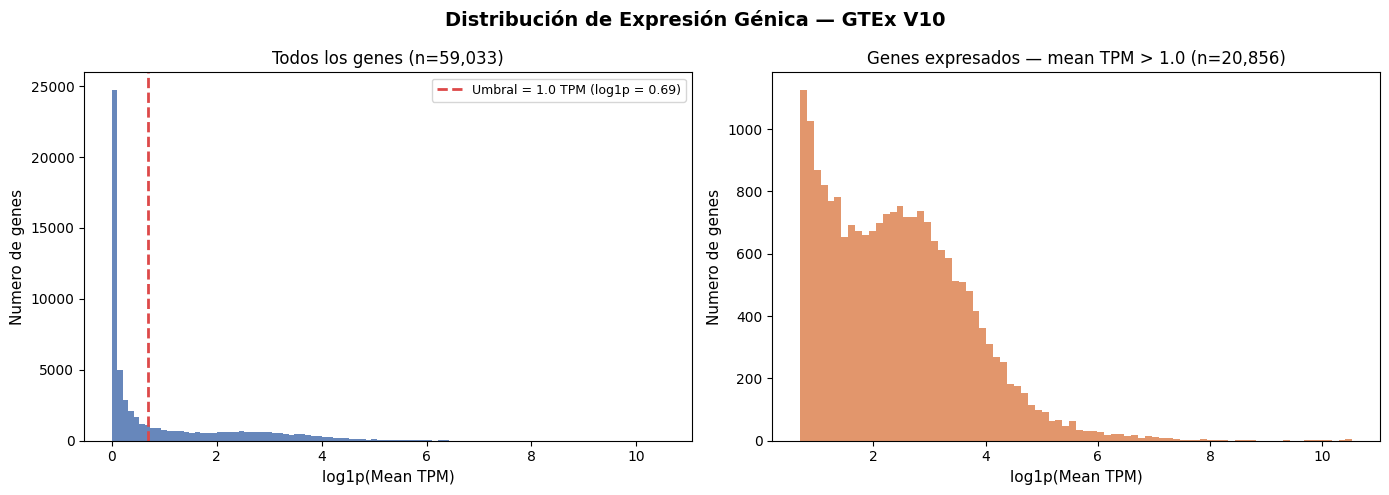

Figura guardada: expression_threshold.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de Expresión Génica — GTEx V10", fontsize=14, fontweight='bold')

log_all = np.log1p(mean_pd["mean_tpm"].dropna())
log_thr = np.log1p(mean_pd[mean_pd["mean_tpm"] > THRESHOLD]["mean_tpm"].dropna())

# all genes — shows the bimodal distribution with noise peak on the left
axes[0].hist(log_all, bins=100, color='#4C72B0', alpha=0.85, edgecolor='none')
axes[0].axvline(np.log1p(THRESHOLD), color='#DD4949', lw=2, linestyle='--',
                label=f'Umbral = {THRESHOLD} TPM (log1p = {np.log1p(THRESHOLD):.2f})')
axes[0].set_xlabel('log1p(Mean TPM)', fontsize=11)
axes[0].set_ylabel('Numero de genes', fontsize=11)
axes[0].set_title(f'Todos los genes (n={total:,})')
axes[0].legend(fontsize=9)

# after threshold — cleaner, just the expressed genes
axes[1].hist(log_thr, bins=80, color='#DD8452', alpha=0.85, edgecolor='none')
axes[1].set_xlabel('log1p(Mean TPM)', fontsize=11)
axes[1].set_ylabel('Numero de genes', fontsize=11)
axes[1].set_title(f'Genes expresados — mean TPM > {THRESHOLD} (n={expressed:,})')

plt.tight_layout()
plt.savefig('expression_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: expression_threshold.png")

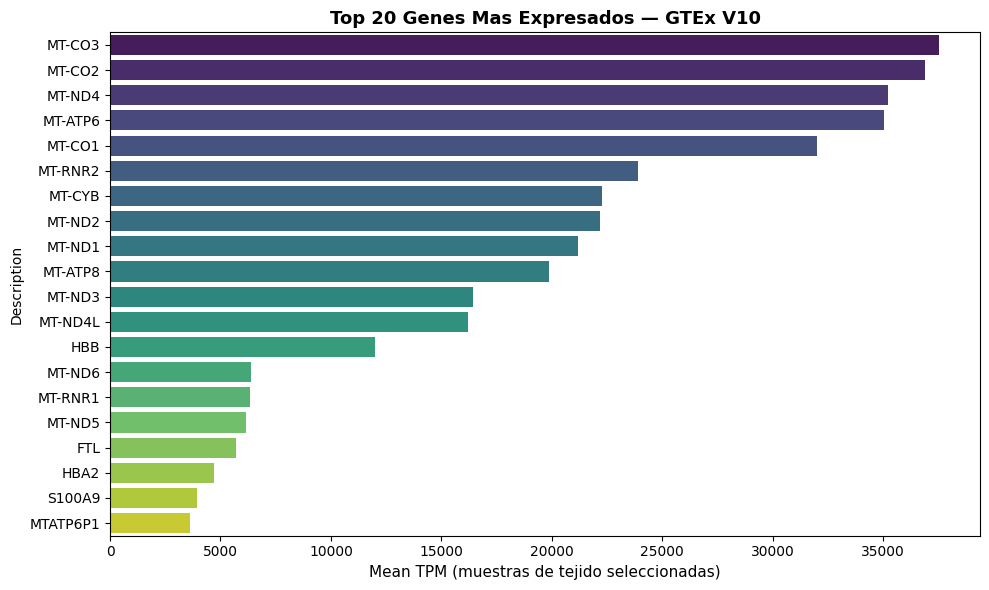

Figura guardada: top_genes.png

Top 20 genes:
Description     mean_tpm
     MT-CO3 37516.236041
     MT-CO2 36901.446701
     MT-ND4 35235.487310
    MT-ATP6 35031.652284
     MT-CO1 31994.337563
    MT-RNR2 23898.449239
     MT-CYB 22279.746193
     MT-ND2 22192.578680
     MT-ND1 21207.777919
    MT-ATP8 19863.784264
     MT-ND3 16421.270305
    MT-ND4L 16196.224619
        HBB 12005.897208
     MT-ND6  6396.231599
    MT-RNR1  6343.484137
     MT-ND5  6153.613579
        FTL  5701.286168
       HBA2  4697.285533
     S100A9  3944.447970
   MTATP6P1  3619.375952


In [12]:
# top 20 most expressed genes — expect albumin (liver), hemoglobin (blood), etc.
top20 = mean_pd.nlargest(20, "mean_tpm")[["Description", "mean_tpm"]].reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=top20, x="mean_tpm", y="Description", palette="viridis", orient="h")
plt.xlabel("Mean TPM (muestras de tejido seleccionadas)", fontsize=11)
plt.title("Top 20 Genes Mas Expresados — GTEx V10", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('top_genes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: top_genes.png")

print("\nTop 20 genes:")
print(top20.to_string(index=False))

## 5. Problemas de Preprocesamiento Identificados

Se identificaron los siguientes problemas en el dataset. Conforme al alcance de esta actividad, se documentan con su corrección propuesta sin implementarla en esta etapa.

| # | Problema | Descripción | Corrección propuesta |
|---|----------|-------------|---------------------|
| 1 | **Filas de metadatos GCT** | El formato GCT 1.2 tiene 2 filas antes del encabezado real | Filtrar con `.filter(startswith('ENSG'))` en RDD (implementado en este notebook) |
| 2 | **IDs ENSEMBL no legibles** | Los genes tienen formato `ENSG00000000003.15`, no interpretable directamente | Mapear a símbolos génicos con tabla de referencia GENCODE GTF |
| 3 | **Outliers extremos de TPM** | Genes como *ALB* (albúmina) o *HBB* (hemoglobina) tienen TPM muy por encima de la media global | Transformación `log1p` (implementada); detección adicional con método IQR |
| 4 | **Muestras desbalanceadas por tejido** | No todos los 54 tejidos tienen el mismo número de donantes | Muestreo estratificado para análisis comparativos |
| 5 | **Ceros estructurales** | `TPM = 0` puede significar no expresado **o** por debajo del umbral de detección | Umbral mínimo de expresión (implementado: `mean TPM > 1.0`); filtrar genes con >90% ceros |
| 6 | **IDs de muestra opacos** | `GTEX-1117F-0005-SM-HL9SH` no contiene info de tejido directamente | Cruzar con `GTEx_v10_sample_attributes.txt` para obtener tipo de tejido |

## Conclusiones

- El dataset GTEx V10 contiene expresión génica de **59,033 genes** en **19,614 muestras** de 54 tipos de tejido humano (~6.8 GB sin comprimir), superando ampliamente el requisito mínimo de 1 GB y justificando el uso de procesamiento distribuido con PySpark.

- Aplicando un umbral de **mean TPM > 1.0**, se filtran los genes de bajo nivel de expresión (ruido técnico y genes no expresados en los tejidos muestreados), dejando un subconjunto de genes con relevancia biológica verificable — esencial antes de cualquier análisis de marcadores para medicina espacial.

- Los genes más expresados corresponden a proteínas estructurales y metabólicas abundantes en sangre e hígado (hemoglobina, albúmina, actina), lo que valida la calidad del dataset como representación de tejidos humanos normales y lo posiciona como línea base adecuada para detectar desviaciones inducidas por el vuelo espacial.

- PySpark procesó el dataset distribuyendo la carga entre todos los núcleos locales disponibles. El mismo código escalaría a un cluster real sin modificaciones, lo que lo hace idóneo para análisis a escala de cohorte como los requeridos en medicina espacial de largo plazo.

## Referencias

1. GTEx Consortium. (2020). The GTEx Consortium atlas of genetic regulatory effects across human tissues. *Science*. https://doi.org/10.1126/science.aaz1776

2. Beheshti, A. et al. (2024). Aging and putative frailty biomarkers are altered by spaceflight. *Nature Scientific Reports*. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC11166946/

3. Ruiz-Fernández de Córdoba, B. et al. (2025). Microgravity impact on gene expression and drug repurposing. *PubMed Central*. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC11818396/

4. GTEx Portal. (2025). GTEx Analysis V10 Downloads. Broad Institute. https://gtexportal.org/home/downloads/adult-gtex

## Declaración de Uso de IA

> **Declaración de uso de IA:**  
> Anthropic. (2026). *Claude Opus 4.6* [Modelo de lenguaje grande], utilizado para apoyo en la estructura del análisis, escritura de código PySpark y redacción de contexto y conclusiones. https://claude.ai  
> La responsabilidad final sobre el contenido entregado recae en los autores del equipo.